금속 성분 함유량 데이터(변수 1개) - 제품에 금속 재질 함유량의 분산이 1.3을 넘으면 불량이라고 보고 있는데 제조사별로 차이가 난다고 제보를 받았다. 분산에 대해 검정을 수행하시오. (유의확률 0.05)

1 연구가설과 귀무가설 작성

2 양측 검정 시행

3 검정통계량, 가설채택

In [4]:
import pandas as pd
import numpy as np

df= pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/22/content.csv')
df

,content
0,97.995295
1,101.478315
2,102.284913
3,98.993634
4,104.635232
...,...
195,100.568703
196,99.082193
197,100.163027
198,99.327200


In [6]:
# 제품에 함유된 금속 성분의 분산이 기준인 1.3보다 큰지를 검정하는 상황 -> 정규성을 가정한 단일 모집단 분산 검정 문제
# Chi-square (카이제곱) 검정

import numpy as np
from scipy.stats import chi2


# 기본 통계량
n = len(df)
sample_var = np.var(df['content'], ddof=1)
sigma0_sq = 1.3

# 검정 통계량
chi2_stat = (n - 1) * sample_var / sigma0_sq

# 유의수준
alpha = 0.05

# 양측 검정 → 양쪽 임계값
chi2_lower = chi2.ppf(alpha / 2, df=n - 1)
chi2_upper = chi2.ppf(1 - alpha / 2, df=n - 1)

# 결과 출력
print(f"카이제곱 검정통계량: {chi2_stat:.4f}")
print(f"임계값 범위: [{chi2_lower:.4f}, {chi2_upper:.4f}]")

if chi2_stat < chi2_lower or chi2_stat > chi2_upper:
    print("귀무가설 기각 → 분산은 1.3과 다르다 (불량 가능성 있음)")
else:
    print("귀무가설 채택 → 분산은 1.3과 다르지 않다 (정상)")

카이제곱 검정통계량: 328.2923
임계값 범위: [161.8262, 239.9597]
귀무가설 기각 → 분산은 1.3과 다르다 (불량 가능성 있음)


Lot별 200개에 대한 불량 제품 수량 데이터(변수 2개 - lot번호, 불량제품수)

1 불량률 관리도에 따라 관리중심선(CL : Center Line), 관리 상한선(UCL : Upper Control Limit), 하한선(LCL : Lower Control Limit) 구하기

2 관리도 시각화

In [37]:
import pandas as pd

df= pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/22/error.csv')
df.head()

,iot_number,error_case_number
0,1,4.5
1,2,2.5
2,3,2.0
3,4,3.0
4,5,0.5


In [38]:
import matplotlib.pyplot as plt

# 고정된 샘플 수
n = len(df)

# 각 lot별 불량률 계산
df['p'] = df['error_case_number'] / n

# 전체 불량률 평균
p_bar = df['p'].mean()

# 관리선 계산
UCL = p_bar + 3 * np.sqrt((p_bar * (1 - p_bar)) / n)
LCL = p_bar - 3 * np.sqrt((p_bar * (1 - p_bar)) / n)
LCL = max(0, LCL)  # LCL은 음수가 될 수 없으므로 0으로 제한

# 결과 출력
print(f"Center Line (CL): {p_bar:.4f}")
print(f"Upper Control Limit (UCL): {UCL:.4f}")
print(f"Lower Control Limit (LCL): {LCL:.4f}")


Center Line (CL): 0.0341
Upper Control Limit (UCL): 0.0885
Lower Control Limit (LCL): 0.0000


공장에서는 진공관 수명이 1만 시간이라고 주장하여 품질관리팀에서 12개 샘플을 뽑았음 유의수준 5%에서 부호 검정하시오

귀무가설 연구가설 세우기

유효한 데이터의 숫자는?

검정통계량 및 연구 가설 채택 여부를 작성하라

In [20]:
import pandas as pd
df =pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/23/problem2.csv')
df

,name,life span
0,sample1,10000
1,sample2,9000
2,sample3,9500
3,sample4,10000
4,sample5,10000
5,sample6,8900
6,sample7,9900
7,sample8,10100
8,sample9,10300
9,sample10,10020


In [21]:
# 중앙값이 10,000시간이라는 주장에 대해 부호검정을 사용하는 비모수 검정 상황.
# 즉, 모집단의 분포를 정규라고 가정하지 않고, 중앙값이 10,000시간인지를 검정

from scipy.stats import binom_test

# 중앙값 기준
median_claim = 10000

# 부호 계산
signs = df['life span'] - median_claim

# +, - 부호 개수 (0은 제외)
positive = np.sum(signs > 0)
negative = np.sum(signs < 0)
valid_n = positive + negative

# 검정통계량: 작은 쪽 부호의 개수
test_stat = min(positive, negative)

# 양측검정 → 이항검정 (p=0.5)
p_value = binom_test(test_stat, n=valid_n, p=0.5, alternative='two-sided')

# 출력
print(f"유효 데이터 수: {valid_n}")
print(f"+ 부호 수: {positive}, - 부호 수: {negative}")
print(f"검정통계량 (더 적은 부호 수): {test_stat}")
print(f"p-value: {p_value:.4f}")

유효 데이터 수: 8
+ 부호 수: 3, - 부호 수: 5
검정통계량 (더 적은 부호 수): 3
p-value: 0.7266


아래 이미지와 같은 학과별 학점 분포 인원수 표가 있다. 학과와 성적이 관계있는지를 검정하라

귀무가설 연구가설 세우기

학과와 성적이 독립일 경우의 기댓값을 구하시오

검정통계량 및 연구 가설 채택 여부를 작성하라

In [22]:
df = pd.DataFrame({'사회과학':[15,60,24],'자연과학':[25,69,5],'공학':[10,77,13]})
df.index = ['1.5-2.5','2.5-3.5','3.5-4.5']
# 1. 귀무가설 : 학과와 성적은 관련이 없다 (독립이다) / 연구가설 : 학과와 성적은 관련이 있다 (독립이 아니다)

In [24]:
df

,사회과학,자연과학,공학
1.5-2.5,15,25,10
2.5-3.5,60,69,77
3.5-4.5,24,5,13


In [23]:
# 2. 학과와 성적이 독립일 경우의 기댓값을 구하시오
from scipy.stats import chi2_contingency,fisher_exact
chi2 , p ,dof, expected = chi2_contingency(df)
print(expected)

# 3. 검정 통계량 및 연구 가설 채택 여부를 작성하라 
print(p)

# 카이 제곱 검정시 p-value는 0.00018로 귀무가설을 기각한다. 학과와 성적은 관련이 있다.
# 만약 5보다 작은 셀이 20%가 넘어 간다면(75%) 피셔의 정확검정을 사용 해야한다. #print(fisher_exact(df))

[[16.61073826 16.61073826 16.77852349]
 [68.43624161 68.43624161 69.12751678]
 [13.95302013 13.95302013 14.09395973]]
0.00018822647762421383


광고횟수와 광고비에 따른 매출액의 데이터이다

1 광고비 변수를 가변수 처리후 다중회귀를 수행하여 회귀계수가 유의한지 검정

2 회귀식이 유의한지 판단

In [29]:
import pandas as pd

df= pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/24/problem2.csv',encoding='cp949')
df.head()

,광고횟수,광고비,매출액
0,2,낮음,15
1,3,낮음,16
2,4,낮음,17
3,4,높음,18
4,5,높음,20


In [31]:
import statsmodels.formula.api as smf

# 광고비를 범주형 → 가변수 처리
df['광고비'] = df['광고비'].astype('category')

# 다중 선형회귀: formula API 사용 (자동으로 더미변수 생성)
model = smf.ols(formula='매출액 ~ 광고횟수 + C(광고비)', data=df).fit()

# 회귀계수 및 유의성 검정 결과 출력
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    매출액   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.978
Method:                 Least Squares   F-statistic:                     221.2
Date:                Thu, 24 Apr 2025   Prob (F-statistic):           9.96e-08
Time:                        11:46:53   Log-Likelihood:                -11.883
No. Observations:                  11   AIC:                             29.77
Df Residuals:                       8   BIC:                             30.96
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       12.1641      0.556     21.876   

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/scipy/stats/stats.py:1542: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=11
  "anyway, n=%i" % int(n))


In [32]:
# 횟수와 광고비 각각의 계수에 대한 p-value 확인 
# C(광고비)[T.높음] 에 대한 유의확률이 0.05보다 높으므로 통계적으로 유의하지 않다고 말할 수 있다.
# 광고횟수는 통계적으로 유의하다.

각 공장별로 12개의 제품을 추출하여 구한 정보가 A생산라인의 제품 평균은 5.7mm이고 표준편차는 0.03, B생산라인의 제품 평균은 5.6mm이고 표준편차는 0.04라면 5%유의수준으로 두 제품의 평균이 차이가 있는지 여부를 검정하기 Z(0.05) = 1.65

1 귀무가설과 대립가설을 세워라

2 두 평균이 차이가 있는지 검정하라

In [33]:
# 두 독립된 생산라인(A, B)의 평균에 차이가 있는지를 검정하는 문제야.
# 각 그룹의 샘플 수(n=12), 평균, 표준편차가 주어졌으므로 두 독립표본의 평균 차이에 대한 Z-검정

# 귀무가설 : 두 생산라인의 평균은 같다/ 다르다.

In [34]:
import numpy as np
from scipy.stats import norm

# 주어진 값
mean_A = 5.7
std_A = 0.03
n_A = 12

mean_B = 5.6
std_B = 0.04
n_B = 12

# Z-검정 통계량 계산
numerator = mean_A - mean_B
denominator = np.sqrt((std_A**2) / n_A + (std_B**2) / n_B)
z_stat = numerator / denominator

# 유의수준 0.05 → 양측검정 → Z 임계값 1.96
z_critical = 1.96  # Z_{0.025} (양측 검정 기준)

# 결과 출력
print(f"Z 검정 통계량: {z_stat:.4f}")
print(f"임계값 범위: ±{z_critical}")

Z 검정 통계량: 6.9282
임계값 범위: ±1.96


In [35]:
# Z 검정 통계량 > 임계값 이므로 귀무가설기각하여 두 생산라인의 평균은 통계적으로 같지 않다고 말할 수 있다.

바이러스 감염 분류표를 보고 베이지안 분류 방법을 사용해 양성으로 예측된 사람이 실제로 양성일 확률을 구하라

In [40]:
df = pd.DataFrame({'양성(실제)':[370,10],'음성(실제)':[10,690]},index = ['양성(예측)','음성(예측)'])
df

,양성(실제),음성(실제)
양성(예측),370,10
음성(예측),10,690


In [44]:
# 주어진 confusion matrix 값
TP = df.iloc[0,0]  # True Positive
FP = df.iloc[1,0]   # False Positive

# Precision (정밀도) = P(실제 양성 | 예측 양성)
precision = TP / (TP + FP)

print(f"양성으로 예측된 사람이 실제로 양성일 확률 (Precision): {precision:.4f}")

양성으로 예측된 사람이 실제로 양성일 확률 (Precision): 0.9737


주어진 데이터에서 신뢰구간을 구하려한다   
정규분포에서 표폰을 추출함[Z(0.05) = -1.65 , Z(0.025) = -1.96, T(0.05, 8) = 1.860 , T0.025(0.025, 8) = 2.306]   
데이터(9개) : [3.1, 3.3, 3.5, 3.7, 3.9, 4.1, 4.3 4.4, 4.7]   

1 모분산을 모르는 경우 주어진 데이터의 95% 신뢰구간을 구하라

2 sigma = 0.04인걸 알고 있을때의 95% 신뢰구간을 구하라

####  주어진 데이터가 정규분포를 따른다고 가정하고,
##### 신뢰구간을 계산할 때 모분산을 모르는 경우 → t-분포,
##### 모분산(σ² 또는 σ)을 아는 경우 → z-분포를 사용

- 모분산 모르는 경우(→ t-분포 사용)

In [45]:
import numpy as np
from scipy.stats import t

# 데이터
data = np.array([3.1, 3.3, 3.5, 3.7, 3.9, 4.1, 4.3, 4.4, 4.7])
n = len(data)
mean = np.mean(data)
std = np.std(data, ddof=1)  # 표본 표준편차
df = n - 1  # 자유도

# T값 (95% 신뢰수준, 양측 → 0.025 양쪽)
t_critical = 2.306  # 문제에서 주어진 값

# 신뢰구간 계산
margin_error_t = t_critical * (std / np.sqrt(n))
ci_lower_t = mean - margin_error_t
ci_upper_t = mean + margin_error_t

print(f"[모분산 모름] 95% 신뢰구간: ({ci_lower_t:.4f}, {ci_upper_t:.4f})")

[모분산 모름] 95% 신뢰구간: (3.4777, 4.3000)


- 모분산 알고 있을 때 (σ = 0.04 → z-분포 사용)

In [46]:
from scipy.stats import norm

sigma = 0.04
z_critical = 1.96  # 문제에서 제공된 Z(0.025)

# 신뢰구간 계산
margin_error_z = z_critical * (sigma / np.sqrt(n))
ci_lower_z = mean - margin_error_z
ci_upper_z = mean + margin_error_z

print(f"[모분산 앎 (σ=0.04)] 95% 신뢰구간: ({ci_lower_z:.4f}, {ci_upper_z:.4f})")

[모분산 앎 (σ=0.04)] 95% 신뢰구간: (3.8628, 3.9150)


서울에서 영동까지 100km/h로 가고 영동에서 서울까지 80km/로 돌아왔을 때, 평균 속도는?

#### 평균 속도는 단순히 (100 + 80) / 2이 아니라, 전체 거리 / 전체 시간으로 계산해야 해.**조화 평균(harmonic mean)**을 구하는 문제

In [47]:
v1 = 100  # 서울 → 영동 속도 (km/h)
v2 = 80   # 영동 → 서울 속도 (km/h)

# 평균 속도 계산 (조화 평균)
average_speed = 2 * v1 * v2 / (v1 + v2)

print(f"왕복 평균 속도: {average_speed:.2f} km/h")

왕복 평균 속도: 88.89 km/h


연매출이 3000, 4000, 5000이었다면 연평균 몇배가 증가한 것인가? 

$$
\text{평균 증가 배수} = \left(\frac{최종값}{초기값}\right)^{\frac{1}{기간 수}} = \left(\frac{5000}{3000}\right)^{\frac{1}{2}}
$$

####  연매출 증가의 연평균 배수(rate of increase)**를 구하는 문제로, 기하평균(geometric mean)**을 사용해서 **연평균 성장률(또는 배수)**을 계산

In [49]:
initial = 3000
final = 5000
years = 2  # 연도 간 차이 (3년 중 증가 구간은 2개)

average_growth_factor = (final / initial) ** (1 / years)

print(f"연평균 증가 배수: {average_growth_factor:.4f} 배")
print("즉, 매년 약 29.1%씩 증가했다")

연평균 증가 배수: 1.2910 배
즉, 매년 약 29.1%씩 증가했다


남성, 여성의 등산, 수영에 대한 취미 선호도 빈도표(2x2)를 보고, 남성 중에서 등산을 좋아할 확률을 구하시오

#### 조건부 확률
$$
P(\text{등산} \mid \text{남자}) = \frac{\text{남자 중 등산 인원}}{\text{전체 남자 인원}} = \frac{20}{20 + 10} = \frac{20}{30}
$$

In [51]:
# 남자 중 등산, 수영 인원
hiking_male = 20
swimming_male = 10

# 전체 남자 수
total_male = hiking_male + swimming_male

# 조건부 확률 계산
p_hiking_given_male = hiking_male / total_male

print(f"남성 중 등산을 좋아할 확률: {p_hiking_given_male:.4f}")

남성 중 등산을 좋아할 확률: 0.6667


표본 10개의 분산이 90일 때 신뢰도 95%로 모분산의 신뢰구간을 추정

##### 정규분포를 가정한 모분산의 신뢰구간 추정 문제 : 모분산 \sigma^2의 신뢰구간은 카이제곱 분포(Chi-square distribution) 를 이용

신뢰구간 공식
$$
\left( \frac{(n-1)s^2}{\chi^2_{(1 - \alpha/2)}}, \frac{(n-1)s^2}{\chi^2_{(\alpha/2)}} \right)
$$

In [52]:
import scipy.stats as stats

# 주어진 값
n = 10
s2 = 90
df = n - 1
alpha = 0.05

# 카이제곱 임계값
chi2_lower = stats.chi2.ppf(alpha / 2, df)
chi2_upper = stats.chi2.ppf(1 - alpha / 2, df)

# 신뢰구간 계산
lower_bound = (df * s2) / chi2_upper
upper_bound = (df * s2) / chi2_lower

print(f"모분산의 95% 신뢰구간: ({lower_bound:.2f}, {upper_bound:.2f})")

모분산의 95% 신뢰구간: (42.58, 299.96)


임상 대상 20명에 대해 혈압약 투약 이전과 이후의 차이가 24, 표준편차 9  신뢰구간 95%, 차이가 존재하는지 확인하려한다

1 귀무가설과 연구가설을 제시하시오

2 검정 후 귀무가설 기각 여부 제시

#### 같은 집단에서 약 복용 전후 차이”**를 비교하는 대응표본 t-검정(Paired t-test) 상황 : 모평균 차이의 유의성 검정 + 신뢰구간 계산

In [53]:
# 귀무가설 : 약 복용 전후의 평균 혈압차이는 0이다 (효과없음)

import scipy.stats as stats
import numpy as np

# 주어진 값
n = 20
mean_diff = 24  # 평균 차이
std_diff = 9    # 차이의 표준편차
df = n - 1
alpha = 0.05

# 표준오차(SE)
se = std_diff / np.sqrt(n)

# t-통계량
t_stat = mean_diff / se

# 임계값 (양측 검정)
t_critical = stats.t.ppf(1 - alpha/2, df)

# p-value 계산
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

# 신뢰구간 계산
ci_lower = mean_diff - t_critical * se
ci_upper = mean_diff + t_critical * se

# 출력
print(f"t-통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"95% 신뢰구간: ({ci_lower:.2f}, {ci_upper:.2f})")

if p_value < alpha:
    print("귀무가설 기각 → 약 복용 전후 혈압에 유의미한 차이가 있다.")
else:
    print("귀무가설 채택 → 약 복용 전후 혈압에 유의미한 차이가 없다.")

t-통계량: 11.9257
p-value: 0.0000
95% 신뢰구간: (19.79, 28.21)
귀무가설 기각 → 약 복용 전후 혈압에 유의미한 차이가 있다.


In [54]:
# 약 복용 전후 혈압 차이는 통계적으로 유의하다

임상 대상 20명에 대해 혈압약 투약 이전과 이후의 차이가 24, 표준편차 9  신뢰구간 95%, 차이가 존재하는지 확인하려한다

1 귀무가설과 연구가설을 제시하시오

2 검정 후 귀무가설 기각 여부 제시

In [55]:
import pandas as pd
df= pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/25/problem5.csv',encoding='cp949')
df.head()

,출하 소요시간,공장명,공장별 출하 소요시간 순위
0,71,Z,11
1,75,X,14
2,71,X,12
3,53,Z,1
4,50,X,1


### 세 개 이상의 그룹(X, Y, Z)**에서 중위수(또는 분포)가 차이가 있는지 확인하는 상황

1. 정규성 검정
### 정규성 + 등분산성이 만족 => 일원분산분석 (ANOVA) 
### 정규성 만족 X => Kruskal-Wallis

In [59]:
from scipy.stats import shapiro

# 각 그룹 분리
group_x = df[df['공장명'] == 'X']['출하 소요시간']
group_y = df[df['공장명'] == 'Y']['출하 소요시간']
group_z = df[df['공장명'] == 'Z']['출하 소요시간']

# 1. 정규성 검정 (Shapiro-Wilk)
p_x = shapiro(group_x).pvalue
p_y = shapiro(group_y).pvalue
p_z = shapiro(group_z).pvalue


print(f"정규성 검정 p값 (X, Y, Z): {p_x:.4f}, {p_y:.4f}, {p_z:.4f}")
# 모두 귀무가설을 기각할 수 없으므로 정규성을 만족한다. 

정규성 검정 p값 (X, Y, Z): 0.9265, 0.6042, 0.9040


2. 등분산성 검정 
### 등분산성 있음 => 일반 ANOVA
### 등분산성 없음 => Welch ANOVA

In [60]:
from scipy.stats import levene

# Levene 검정 수행
stat, p = levene(group_x, group_y, group_z)

# 결과 출력
print(f"Levene 통계량: {stat:.4f}")
print(f"p-value: {p:.4f}")

# 유의수준 0.05 기준 판단
if p < 0.05:
    print("귀무가설 기각 → 그룹 간 분산에 유의미한 차이가 있음 (등분산성 X)")
else:
    print("귀무가설 채택 → 그룹 간 분산 차이 없음 (등분산성 O)")

Levene 통계량: 1.3942
p-value: 0.2595
귀무가설 채택 → 그룹 간 분산 차이 없음 (등분산성 O)


In [61]:
# 등분산성 만족하므로 일반 ANOVA 해야해
# 귀무가설 : 모든 공장의 출하 소요시간 평균은 같다.

from scipy.stats import f_oneway

# 공장별 출하 소요시간 데이터
group_x = df[df['공장명'] == 'X']['출하 소요시간']
group_y = df[df['공장명'] == 'Y']['출하 소요시간']
group_z = df[df['공장명'] == 'Z']['출하 소요시간']

# ANOVA 수행
stat, p = f_oneway(group_x, group_y, group_z)

# 결과 출력
print(f"ANOVA F-통계량: {stat:.4f}")
print(f"p-value: {p:.4f}")

# 유의수준 0.05 기준 해석
if p < 0.05:
    print("귀무가설 기각 → 공장별 출하 소요시간 평균에 유의미한 차이가 있음.")
else:
    print("귀무가설 채택 → 공장별 출하 소요시간 평균 차이가 없음.")

ANOVA F-통계량: 0.4767
p-value: 0.6242
귀무가설 채택 → 공장별 출하 소요시간 평균 차이가 없음.


## 만약 정규성 만족안했을 떄

In [56]:
# 귀무가설 : 공장 X, Y, Z의 중위수는 같다 

import pandas as pd
from scipy.stats import kruskal


# 공장별 출하 소요시간 리스트 분리
group_x = df[df['공장명'] == 'X']['출하 소요시간']
group_y = df[df['공장명'] == 'Y']['출하 소요시간']
group_z = df[df['공장명'] == 'Z']['출하 소요시간']

# Kruskal-Wallis H 검정
stat, p = kruskal(group_x, group_y, group_z)

# 결과 출력
print(f"Kruskal-Wallis H 통계량: {stat:.4f}")
print(f"p-value: {p:.4f}")

# 유의수준 설정
alpha = 0.05

if p < alpha:
    print("귀무가설 기각 → 공장별 출하 소요시간(중위수)에 유의미한 차이가 있다.")
else:
    print("귀무가설 채택 → 공장별 출하 소요시간(중위수)에 유의미한 차이가 없다.")

Kruskal-Wallis H 통계량: 0.7218
p-value: 0.6971
귀무가설 채택 → 공장별 출하 소요시간(중위수)에 유의미한 차이가 없다.


## 만약 정규성 만족 +  등분산성 깨졌다면 ->Welch ANOVA

In [ ]:
# !pip install pingouin

import pingouin as pg
import pandas as pd

# Welch ANOVA 수행
welch_result = pg.welch_anova(dv='출하 소요시간', between='공장명', data=df)

# 결과 출력
print(welch_result)

1개년 50억원, 2개년 60억원, 3개년 70억원의 예산을 가지고 NPV(순현재가치)가 가장 높아지는 안을 제시하시오

In [62]:
import pandas as pd

# 안별 연도별 NPV
df = pd.DataFrame({
    '1개년': [10, 15, 12, 13, 16],
    '2개년': [20, 14, 11, 25, 30],
    '3개년': [15, 19, 30, 20, 24]
}, index=['1안', '2안', '3안', '4안', '5안'])

df

,1개년,2개년,3개년
1안,10,20,15
2안,15,14,19
3안,12,11,30
4안,13,25,20
5안,16,30,24


In [63]:
# 각 연도별 예산
budget = [50, 60, 70]  # 1개년, 2개년, 3개년


# 모든 안 중에서 중복 없이 3개를 선택하여
# 각 연도에 하나씩 배정했을 때의 총 NPV가 최대인 조합을 찾는 코드

from itertools import permutations

max_npv = -1
best_comb = None

# 안들의 인덱스를 순열로 생성 (3개 선택, 중복 없이)
for perm in permutations(df.index, 3):
    # 각 연도별 NPV 합산
    npv_sum = (
        df.loc[perm[0], '1개년'] +
        df.loc[perm[1], '2개년'] +
        df.loc[perm[2], '3개년']
    )
    
    # 최대값 갱신
    if npv_sum > max_npv:
        max_npv = npv_sum
        best_comb = perm

# 결과 출력
print("최고 NPV 조합 (1~3개년 순):", best_comb)
print("최대 NPV 합계:", max_npv)

최고 NPV 조합 (1~3개년 순): ('2안', '5안', '3안')
최대 NPV 합계: 75


### 예산 이내에서 최대 NPV 조합을 찾는 문제
각 연도별로 예산이 정해져 있음:
1개년: 50억, 2개년: 60억, 3개년: 70억

In [65]:
import pandas as pd

# 각 안의 연도별 NPV (단위: 억원)
npv = pd.DataFrame({
    '1개년': [10, 15, 12, 13, 16],
    '2개년': [20, 14, 11, 25, 30],
    '3개년': [15, 19, 30, 20, 24]
}, index=['1안', '2안', '3안', '4안', '5안'])

# 각 안의 연도별 투자 비용 (단위: 억원)
cost = pd.DataFrame({
    '1개년': [40, 55, 45, 50, 49],
    '2개년': [45, 58, 50, 60, 59],
    '3개년': [55, 62, 65, 60, 66]
}, index=['1안', '2안', '3안', '4안', '5안'])

# 예산
budget = [50, 60, 70]

In [66]:
npv

,1개년,2개년,3개년
1안,10,20,15
2안,15,14,19
3안,12,11,30
4안,13,25,20
5안,16,30,24


In [67]:
cost

,1개년,2개년,3개년
1안,40,45,55
2안,55,58,62
3안,45,50,65
4안,50,60,60
5안,49,59,66


In [69]:
# 예산제약 고려한 최적 조합 탐색

In [68]:
from itertools import permutations

max_total_npv = -1
best_plan = None

# 모든 3개의 안 조합 순열 탐색
for perm in permutations(npv.index, 3):
    cost_ok = True
    total_npv = 0

    for year_idx, year in enumerate(['1개년', '2개년', '3개년']):
        plan = perm[year_idx]
        # 비용이 예산 초과되면 break
        if cost.loc[plan, year] > budget[year_idx]:
            cost_ok = False
            break
        total_npv += npv.loc[plan, year]

    if cost_ok and total_npv > max_total_npv:
        max_total_npv = total_npv
        best_plan = perm

# 출력
print("최적 안 조합 (1~3개년 순):", best_plan)
print("최대 총 NPV:", max_total_npv)

최적 안 조합 (1~3개년 순): ('4안', '5안', '3안')
최대 총 NPV: 73


통계
철강제품의 불량률을 조사하고자 한다. 이 때, 불량률의 90%, 추정오차한계가 5% 이내가 되기 위하여 적절한 표본의 크기 중 최소값은 얼마인가?

## 비율 추정을 위한 표본 크기 계산 문제
우리는 **불량률(비율)**을 추정하고자 하며, **추정 오차의 최대 허용 한계(MOE)**와 신뢰수준이 주어졌을 때,
필요한 최소 표본 크기
$$ 
n = \left( \frac{Z \cdot \sqrt{p(1 - p)}}{E} \right)^2
$$

In [73]:
import math

# 주어진 값
Z = 1.645      # 90% 신뢰수준
E = 0.05       # 허용 오차
p = 0.5        # 불량률 (보통 최대 분산 가정)

# 표본 크기 계산
n = (Z**2 * p * (1 - p)) / (E**2)
n_ceil = math.ceil(n)  # 올림 처리 (정수 표본 수)

print(f"최소 표본 크기: {n_ceil}명")

최소 표본 크기: 271명


아래 그래프는 1월부터 9월까지의 은의 가격이다

1 은의 가격 및 이동평균값 3이 설정된 시계열 그래프를 그려라

2 1월 대비 9월의 은의 가격은 몇 % 올랐는가? 소수점 두번째 자리에서 반올림

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# 월별 은 가격 데이터
months = ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월']
silver_prices = [12.14, 42.6, 34.4, 35.29, 30.96, 57.12, 37.84, 42.49, 31.38]

# 데이터프레임 생성
df = pd.DataFrame({'month': months, 'price': silver_prices})
df['MA_3'] = df['price'].rolling(window=3).mean()

In [75]:
df

,month,price,MA_3
0,1월,12.14,NaN
1,2월,42.60,NaN
2,3월,34.40,29.713333
3,4월,35.29,37.430000
4,5월,30.96,33.550000
5,6월,57.12,41.123333
6,7월,37.84,41.973333
7,8월,42.49,45.816667
8,9월,31.38,37.236667


/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/matplotlib/axes/_base.py:237: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/matplotlib/axes/_base.py:239: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


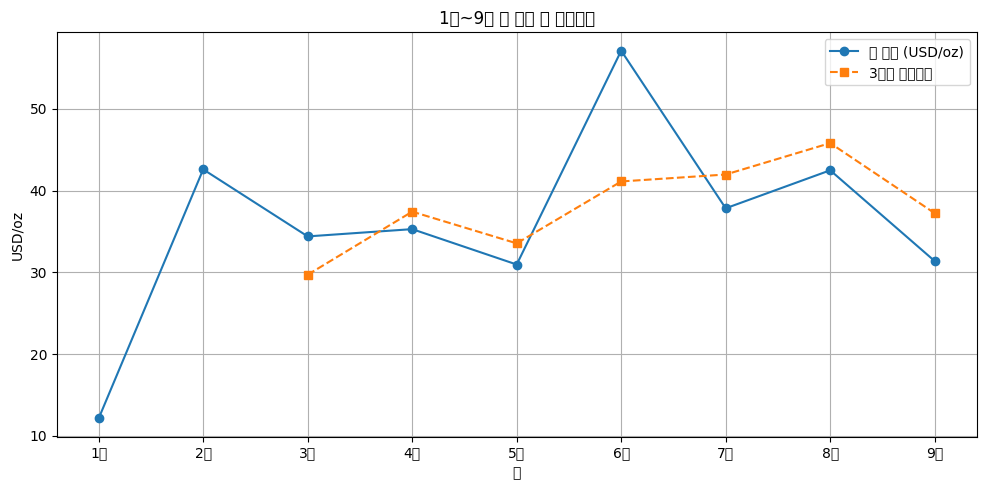

In [76]:
plt.figure(figsize=(10, 5))
plt.plot(df['month'], df['price'], marker='o', label='은 가격 (USD/oz)')
plt.plot(df['month'], df['MA_3'], marker='s', linestyle='--', label='3개월 이동평균')
plt.title('1월~9월 은 가격 및 이동평균')
plt.xlabel('월')
plt.ylabel('USD/oz')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

1월 대비 9월 가격 변화율 계산
$$
\text{변화율} = \left( \frac{9월\_가격 - 1월\_가격 }{1월\_가격} \right) \times 100
$$

In [77]:
price_jan = df.loc[0, 'price']
price_sep = df.loc[8, 'price']
change_percent = round(((price_sep - price_jan) / price_jan) * 100, 2)

print(f"1월 대비 9월의 은 가격 변화율: {change_percent}%")

1월 대비 9월의 은 가격 변화율: 158.48%


아래 그래프는 A,B,C 자치구별 W 의원에 대한 찬성, 반대 지지를 나타낸다. 자치구별 지지율이 같은지에 대해서 검정하라

1 연구가설과 귀무가설을 설정하라

2 검정통계량 구하고 결론을 내라

In [80]:
# 교차표 데이터 생성
data = pd.DataFrame({
    'A': [176, 124],
    'B': [193, 107],
    'C': [159, 141]
}, index=['찬성', '반대'])
data

,A,B,C
찬성,176,193,159
반대,124,107,141


#### 범주형 변수(자치구 vs 찬반 지지)**에 대한 독립성 검정을 수행해야 하는 상황
즉, **자치구(A, B, C)에 따라 찬반 비율이 다르다고 볼 수 있는가?**를 확인하는 카이제곱 독립성 검정(Chi-Square Test of Independence) 문제

In [78]:
# 귀무가설 : 자치구 A,B,C 와 찬반 지지여부는 독립이다.

In [82]:
import pandas as pd
from scipy.stats import chi2_contingency

# 카이제곱 독립성 검정
chi2_stat, p, dof, expected = chi2_contingency(data)

# 결과 출력
print(f"카이제곱 통계량: {chi2_stat:.4f}")
print(f"p-value: {p:.4f}")
print(f"자유도: {dof}")

# 유의수준 0.05에서 해석
alpha = 0.05
if p < alpha:
    print("\n결론: 귀무가설 기각 → 자치구에 따라 지지율이 유의하게 다르다.")
else:
    print("\n결론: 귀무가설 채택 → 자치구별 지지율에 유의한 차이가 없다.")

카이제곱 통계량: 7.9454
p-value: 0.0188
자유도: 2

결론: 귀무가설 기각 → 자치구에 따라 지지율이 유의하게 다르다.


In [83]:
# 자치구별 지지율은 통계적으로 차이가 있음

A초등학교 남학생 16명과 여학생 9명의 혈압을 측정한 pressure.csv파일을 가지고 남녀학생의 평균 혈압에 차이가 없는지 분석하라. 단, 남학생과 여학생의 혈압 데이터는 정규분포를 따르며 등분산임을 가정한다.

1 연구가설과 귀무가설을 설정하라

2 통계량을 구하고, 연구가설 채택여부를 기술하라.

3 2 에서 구한 검정 통계량 값을 바탕으로 신뢰구간을 구하라

In [85]:
import pandas as pd

df= pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/26/pressure.csv')
df.head()

,gender,pressure
0,male,106.8
1,male,100.8
2,male,84.5
3,male,104.2
4,male,107.0


### 두 독립집단(남학생 vs 여학생)의 평균 비교 문제로, 정규성 + 등분산 가정이 만족됨이 명시 -> → **독립표본 t-검정(Independent t-test)**을 사용

In [88]:
# 귀무가설 : 남학생과 여학생의 평균 혈압은 차이가 없다

from scipy.stats import ttest_ind
import numpy as np

# 남학생, 여학생 혈압 분리
male_bp = df[df['gender'] == 'male']['pressure']
female_bp = df[df['gender'] == 'female']['pressure']

# 독립표본 t-검정 (등분산 가정 True)
t_stat, p_value = ttest_ind(male_bp, female_bp, equal_var=True)

print(f"t-검정 통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# 유의수준 0.05 기준 결론
alpha = 0.05
if p_value < alpha:
    print("귀무가설 기각 → 남녀 평균 혈압은 유의하게 다르다.")
else:
    print("귀무가설 채택 → 남녀 평균 혈압은 유의하게 다르지 않다.")

t-검정 통계량: 1.5983
p-value: 0.1236
귀무가설 채택 → 남녀 평균 혈압은 유의하게 다르지 않다.


## 신뢰구간 계산 

In [89]:
# 표본 평균과 표준편차
mean_diff = male_bp.mean() - female_bp.mean()
pooled_std = np.sqrt(((male_bp.var(ddof=1) * (len(male_bp) - 1)) + 
                      (female_bp.var(ddof=1) * (len(female_bp) - 1))) / 
                     (len(male_bp) + len(female_bp) - 2))
se = pooled_std * np.sqrt(1/len(male_bp) + 1/len(female_bp))

# 자유도
dfree = len(male_bp) + len(female_bp) - 2

from scipy.stats import t
t_crit = t.ppf(1 - alpha/2, dfree)

# 신뢰구간
ci_lower = mean_diff - t_crit * se
ci_upper = mean_diff + t_crit * se

print(f"95% 신뢰구간 (남 - 여): ({ci_lower:.4f}, {ci_upper:.4f})")

95% 신뢰구간 (남 - 여): (-1.8561, 14.4713)


2년 전 제품 생산량이 100,000개, 1년 전 제품 생산량이 150,000개, 그 후 팩토리 기술의 상승으로 제품 생산량이 250,000개 되었을 때, 연평균 상승률의 대푯값을 구하시오. (반올림하여 소수점 아래 둘째자리까지 표기하시오.)

#### 연평균 상승률을 구하는 문제로, 이는 **기하 평균 (Geometric Mean)**을 활용해서 구할 수 있어.
즉, 복리 방식으로 매년 얼마나 성장했는가를 나타내는 값
$$
\text{연평균 상승률} = \left( \frac{최종값}{초기값} \right)^{\frac{1}{연도 수}} - 1
$$

In [100]:
initial = 100000  # 2년 전
final = 250000    # 현재
years = 2         # 2년 간의 변화

# 기하 평균 기반 연평균 상승률
growth_rate = (final / initial) ** (1 / years) - 1

# 소수점 둘째 자리까지 반올림
growth_percent = round(growth_rate * 100, 2)

print(f"연평균 상승률: {growth_percent}%")

연평균 상승률: 58.11%


강의 상류와 하류의 생물 다양성 점수에 차이가 있는지 검정하시오. (단, 같은 강에서 상류와 하류는 서로 독립적이지 않으며, 종속적인 관계에 있다.)

1 귀무가설과 대립가설을 세우시오

2 검정 통계량과 유의 확률을 구하고, 연구가설 채택여부를 검정하시오.

###  같은 강에서 상류와 하류의 생물 다양성 점수를 비교하는 것이며,
#### “서로 독립적이지 않다”는 조건에 따라 대응표본 t-검정(Paired t-test) 을 수행

In [101]:
import pandas as pd

df= pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/27/river.csv')
df.head()

,River,up,down
0,A,57.1,45.7
1,B,51.6,37.2
2,C,53.9,53.3
3,D,59.0,54.3
4,E,57.5,46.3


### 반복있는지 없는지 확인

In [102]:
df['River'].value_counts()

J    1
M    1
B    1
C    1
H    1
E    1
N    1
G    1
Q    1
I    1
O    1
F    1
D    1
A    1
R    1
S    1
P    1
K    1
L    1
Name: River, dtype: int64

In [105]:
from scipy.stats import ttest_rel

# 대응표본 t-검정
t_stat, p_value = ttest_rel(df['up'], df['down'])

print(f"t-검정 통계량: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# 유의수준 판단
alpha = 0.05
if p_value < alpha:
    print("귀무가설 기각 → 상류와 하류 생물 다양성 점수에 유의한 차이가 있다.")
else:
    print("귀무가설 채택 → 상류와 하류 생물 다양성 점수에 유의한 차이가 없다.")

t-검정 통계량: 1.2922
p-value: 0.2126
귀무가설 채택 → 상류와 하류 생물 다양성 점수에 유의한 차이가 없다.


user_counts를 종속변수로 하는 데이터이다

1 분위수 회귀분석 (Quantile Regression) 을 사용하여 회귀 계수를 구하시오. (반올림하여 소수점 아래 둘째자리까지 표기하시오.)

2 1의 모델의 회귀계수를 활용하여 temperature : 10.5 , wind : 8.2 , precipitation : 3.5 일때 user_counts를 예측하시오

In [107]:
import pandas as pd

df= pd.read_csv('https://raw.githubusercontent.com/Datamanim/datarepo/main/adp/27/problem8.csv')
df.head()

,temperature,wind,precipitation,user_counts
0,10.400000,4.600,0.844944,6368
1,5.666667,4.625,0.040860,5902
2,4.933333,4.725,0.008696,6226
3,3.400000,2.675,0.156989,5829
4,8.900000,3.950,7.988462,7589


In [108]:
# Quantile Regression (분위수 회귀)
# 일반적인 선형회귀가 평균에 대한 조건부 예측을 하는 반면,
#분위수 회귀는 특정 분위수(예: 0.5 분위수, 즉 중앙값)를 예측해줌. 이상치에 덜 민감하고, 분포의 다른 부분을 모델링할 수 있음.

In [109]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg

# 독립변수(X)와 종속변수(y)
X = df[['temperature', 'wind', 'precipitation']]
X = sm.add_constant(X)  # 상수항 추가
y = df['user_counts']

# 분위수 회귀 모델 학습 (0.5 분위수 = median regression)
model = QuantReg(y, X)
res = model.fit(q=0.5)

# 회귀 계수 출력 (소수점 둘째자리까지)
coeffs = np.round(res.params, 2)
print("회귀 계수 (0.5 분위수 기준):")
print(coeffs)

# 주어진 입력값으로 예측
input_data = pd.DataFrame({
    'const': [1],
    'temperature': [10.5],
    'wind': [8.2],
    'precipitation': [3.5]
})

prediction = res.predict(input_data)
print(f"\n예측된 user_counts (temperature=10.5, wind=8.2, precipitation=3.5): {int(prediction[0])}")

회귀 계수 (0.5 분위수 기준):
const            5941.84
temperature       268.89
wind             -129.41
precipitation     -83.38
dtype: float64

예측된 user_counts (temperature=10.5, wind=8.2, precipitation=3.5): 7412
